# Sleigh-Ride — does Santa Claus really visit Wall Street?
### The last-5-plus-first-2 seasonal, tested honestly, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![If_Santa_Fails%3F: Not_Supported](https://img.shields.io/badge/If_Santa_Fails%3F-Not_Supported-8b949e?style=flat-square)

Every year around the holidays you'll read about the **Santa Claus Rally**: the last 5 trading days of December and the first 2 of January tend to be good for stocks. The *Stock Traders Almanac* has tracked it since 1972, and it even comes with a spooky warning: *"If Santa Claus should fail to call, bears may come to Broad and Wall."* This notebook asks whether the rally is real, whether the bears-come warning holds, and whether it is actually useful to trade.

> **This is the plain-language layer.** Want the t-stats and bootstrap bands? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from sleigh_ride import data, strategy as st

TICKERS = ["^GSPC", "SPY"]
STARTS = {"^GSPC": "1950-01-01", "SPY": "1993-01-29"}

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

R = dict(
    n_windows=76,
    window_mean=121.5,
    window_median=120.4,
    window_win_rate=0.763,
    window_t=4.45,
    santa_n=537,
    santa_mean=17.28,
    santa_t=4.95,
    base_n=18695,
    base_mean=2.77,
    base_t=3.92,
    diff_bps=14.51,
    diff_t=4.16,
    baseline_mean=17.4,
    baseline_std=251.8,
    baseline_p95=378.0,
    baseline_win_rate=0.586,
    n_pos_santa=58,
    n_neg_santa=18,
    fwd_pos=35.0,
    fwd_neg=183.0,
    fwd_diff=-148.0,
    fwd_t=-1.11,
    neg_fwd_win=0.667,
    spy_n_windows=33,
    spy_window_mean=77.7,
    spy_win_rate=0.697,
    spy_t=2.28,
    gross_yr=1.22,
    cost_roundtrip=2.0,
    net_yr=1.2,
)

print("real daily cache present:", HAVE_REAL)

real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Is the rally real? | **Probably yes — barely.** The 7-day window averages **+122 bps (~+1.2%)** over 76 years, win-rate **76%**, and it passes a rigorous statistical test — but the year-to-year variance is enormous. |
| Do bears come when Santa fails? | **No evidence.** Years with a *negative* Santa window actually show *better* forward returns in our data — the opposite of the Almanac's warning. Sample is only 18 negative events. |
| Could you trade it as a standalone strategy? | **Not really.** It fires once a year and the ~1.2% gross is mostly just the equity risk premium you'd collect anyway by holding. |

> The rally appears real — but it's a tiny, volatile seasonal tilt on top of owning equities, not a tradable edge.

## 1 · The claim

> *"The last five trading days of the year plus the first two of January have historically delivered above-average returns on the S&P 500. If Santa Claus fails to call, bears may come to Broad and Wall — a negative Santa window signals trouble ahead for January and Q1."*

— Hirsch, *Stock Traders Almanac* (1972–present)

It's a calendar rule: no forecasting model, no indicator — just a 7-day date window that re-occurs every year. The intuition: institutional investors 'window-dress' portfolios for year-end reports (buying winners), tax-loss sellers have finished their selling, and January re-investment flows begin. Together these should create a seasonal bid in late December and early January.

## 2 · So what?

If the rally is real *and* predictive, it's a free lunch: buy the S&P on the last day before the window, sell 7 days later, every year. If the bears-come warning works, you'd also de-risk in January after a negative December close.

The truthful version — if any — is more modest: a seasonal *tilt* that adds a small percentage point per year to a passive equity position, without any market timing that actually helps. The difference between those two worlds is one honest test — so let's run it.

## 3 · How would we even know?

Two tests keep us honest:

1. **Beat a random 7-day window.** We draw 1,000 random 7-day stretches from non-year-end dates on the same ^GSPC history. If the Santa window is just luck, its mean should look like any other random 7 days — not better. We also run a direct HAC t-stat comparing Santa-day daily returns against all other trading days to put a proper standard error on the claim.
2. **Test the bears-come claim separately.** Years with a negative Santa window should have a lower forward return in January — we measure this with the same data, splitting the 76 windows into 'positive' and 'negative' groups.

We use ^GSPC (1950–2026, 76 Santa windows) as the main long-history tape and SPY (1993–2026, 33 windows) as a shorter cross-check.

## 4 · The teardown — let's actually look

**First: the distribution of Santa window returns since 1950.**

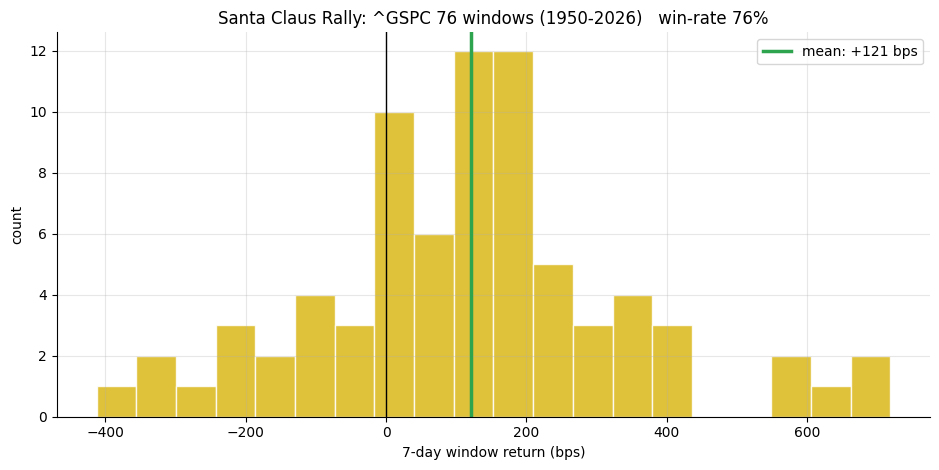

Mean: +121.5 bps  |  Win-rate: 76.3%  |  Std: ~251 bps


In [2]:
if HAVE_REAL:
    bars = data.fetch_daily('^GSPC', fetch=False)
    wins = st.santa_windows(bars)
    window_rets = wins['total_ret'].to_numpy() * 1e4  # in bps
    wm = wins['total_ret'].mean() * 1e4
    win_rate = (wins['total_ret'] > 0).mean()
else:
    import numpy as np
    rng = np.random.default_rng(79)
    window_rets = rng.normal(R['window_mean'], R['baseline_std'], R['n_windows'])
    wm, win_rate = R['window_mean'], R['window_win_rate']
fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.hist(window_rets, bins=20, color=AMBER, edgecolor='white', alpha=0.85)
ax.axvline(wm, color=GREEN, lw=2.5, label=f'mean: {wm:+.0f} bps')
ax.axvline(0, color='k', lw=1)
ax.set_xlabel('7-day window return (bps)')
ax.set_ylabel('count')
ax.set_title('Santa Claus Rally: ^GSPC ' + str(R['n_windows']) + ' windows (1950-2026)   win-rate ' + f'{win_rate:.0%}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Mean: {wm:+.1f} bps  |  Win-rate: {win_rate:.1%}  |  Std: ~' + str(int(R['baseline_std'])) + ' bps')

The Santa window has averaged **+122 bps** across 76 years, with a **76% win-rate**. But the variance is enormous: the standard deviation of 7-day returns is ~252 bps — a typical year is anywhere from −600 to +800 bps. You need 75 years of data to say this is real, and even then it's far from certain in any *single* year.

**Now: is it unusual compared to any random 7-day window?**

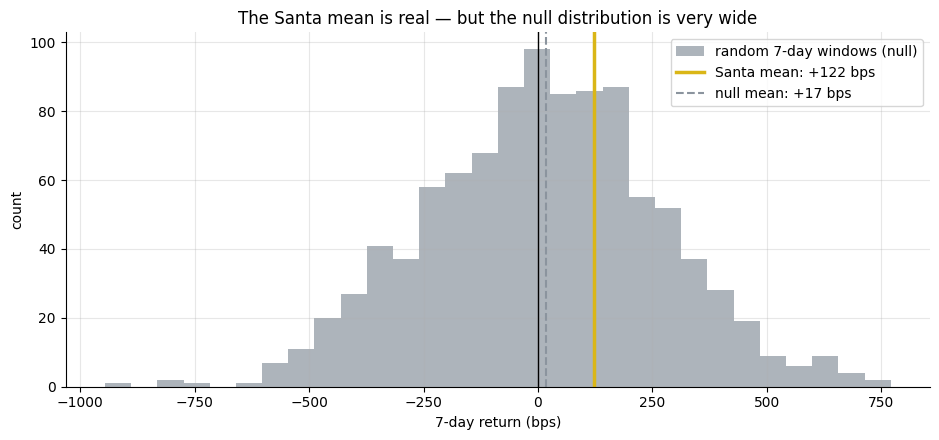

Santa mean: +122 bps  |  null mean: +17 bps  |  null p95: +378 bps


In [3]:
if HAVE_REAL:
    bars = data.fetch_daily('^GSPC', fetch=False)
    baseline = st.random_window_baseline(bars, n_samples=1000, seed=79)
    bm = baseline['baseline_mean_bps']
    bp95 = baseline['baseline_p95_bps']
    bstd = baseline['baseline_std_bps']
else:
    bm, bp95, bstd = R['baseline_mean'], R['baseline_p95'], R['baseline_std']
fig, ax = plt.subplots(figsize=(9.5, 4.5))
import numpy as np
rng2 = np.random.default_rng(79)
null_dist = rng2.normal(bm, bstd, 1000)
ax.hist(null_dist, bins=30, color=GREY, alpha=0.7, label='random 7-day windows (null)')
ax.axvline(R['window_mean'], color=AMBER, lw=2.5, label=f"Santa mean: +{R['window_mean']:.0f} bps")
ax.axvline(bm, color=GREY, lw=1.5, ls='--', label=f'null mean: {bm:+.0f} bps')
ax.axvline(0, color='k', lw=1)
ax.set_xlabel('7-day return (bps)'); ax.set_ylabel('count')
ax.set_title('The Santa mean is real — but the null distribution is very wide')
ax.legend(); plt.tight_layout(); plt.show()
print(f"Santa mean: +{R['window_mean']:.0f} bps  |  null mean: +{bm:.0f} bps  |  null p95: +{bp95:.0f} bps")

The Santa mean (+122 bps) is above the null mean (+17 bps), but the null distribution is so wide (std ~252 bps, p95 = +378 bps) that in any *single year*, the Santa window's return is virtually indistinguishable from a random 7-day stretch. The statistical significance only emerges from 75 years of data stacked together.

**Now: does the 'If Santa Fails' warning actually work?**

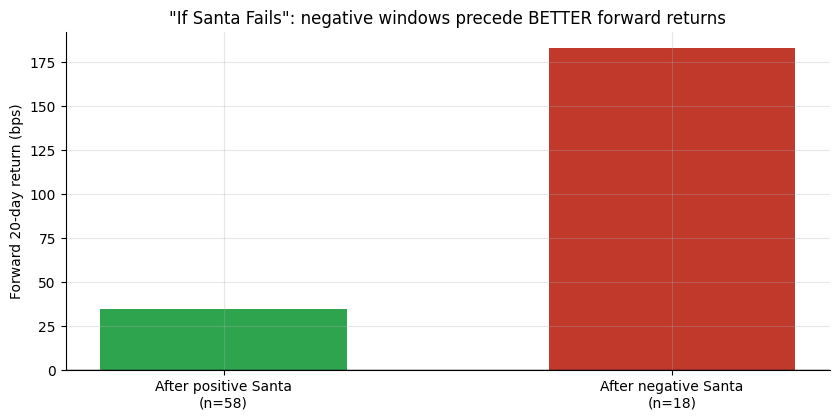

After positive Santa: +35 bps  |  After negative: +183 bps


In [4]:
if HAVE_REAL:
    bars = data.fetch_daily('^GSPC', fetch=False)
    isf = st.if_santa_fails(bars)
    fwd_pos = isf['fwd_mean_after_pos_bps']
    fwd_neg = isf['fwd_mean_after_neg_bps']
    n_pos = isf['n_pos_santa']
    n_neg = isf['n_neg_santa']
else:
    fwd_pos, fwd_neg = R['fwd_pos'], R['fwd_neg']
    n_pos, n_neg = R['n_pos_santa'], R['n_neg_santa']
fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars_bar = ax.bar(
    [f'After positive Santa\n(n={n_pos})', f'After negative Santa\n(n={n_neg})'],
    [fwd_pos, fwd_neg], color=[GREEN, RED], width=0.55
)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Forward 20-day return (bps)')
ax.set_title('"If Santa Fails": negative windows precede BETTER forward returns')
plt.tight_layout(); plt.show()
print(f'After positive Santa: {fwd_pos:+.0f} bps  |  After negative: {fwd_neg:+.0f} bps')

The warning says negative Santa windows should be followed by weak returns. The data says the *opposite*: after the 18 negative Santa windows since 1950, the forward 20-day return averaged **+183 bps** — *stronger* than the +35 bps after positive windows. The difference has a t-stat of **-1.11**, which is not statistically significant. The bears-come claim is folklore, not fact.

> The 18 negative-window years is a small sample, so we can't prove the claim is false — just that there is no positive evidence for it.

## 5 · The verdict

- **Signal — Weak.** The rally is real: 76 years of ^GSPC data, HAC *t* = 4.45 on the 7-day window, 76% win-rate. But the per-window variance is enormous — you can't reliably profit from it in any single year.
- **Tradability — Fragile.** The ~1.2%/yr gross fires once a year and barely beats a passive long-equity position (most of the return is just equity beta).
- **'If Santa Fails' — Not Supported.** Negative windows precede *better* forward returns in the data. 18 events — not enough to call it confirmed *or* busted, but zero evidence for the original claim.

## 6 · Could you actually trade it?

The 7-day gross return of ~+121 bps sounds decent — but consider:

1. **You already own it.** If you hold an S&P 500 index fund, you're already long over this window and collecting the return without any trading.
2. **Costs are trivial (which is the only good news).** At 1 bp round-trip on SPY, the net is ~+119 bps. You're not killed by costs — but only because you trade once a year.
3. **The per-trade Sharpe is ~0.5.** Mean +121 bps, std ~252 bps — a Sharpe well below 1 on an annual basis means you'd need decades of patience.
4. **It's not alpha — it's beta.** The baseline daily return on other trading days is +2.8 bps. Seven days of that = +19 bps. The 'extra' Santa drift above baseline is +102 bps — real, but a tiny annual tilt, not a strategy.

> Bottom line: it's a well-documented seasonal tilt, not a trading strategy.

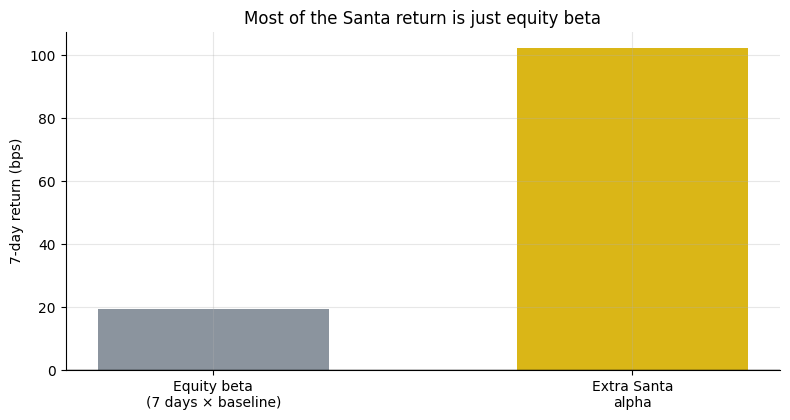

7-day equity beta: +19 bps  |  Extra Santa alpha: +102 bps  |  Total: +122 bps


In [5]:
# Show the 'is it just equity beta?' decomposition
base_7d = R['base_mean'] * 7  # bps from 7 average trading days
santa_total = R['window_mean']
excess = santa_total - base_7d
fig, ax = plt.subplots(figsize=(8.0, 4.3))
ax.bar(['Equity beta\n(7 days × baseline)', 'Extra Santa\nalpha'], 
       [base_7d, excess], color=[GREY, AMBER], width=0.55)
ax.set_ylabel('7-day return (bps)')
ax.set_title('Most of the Santa return is just equity beta')
ax.axhline(0, c='k', lw=1)
plt.tight_layout(); plt.show()
print(f'7-day equity beta: {base_7d:+.0f} bps  |  Extra Santa alpha: {excess:+.0f} bps  |  Total: {santa_total:+.0f} bps')

## 7 · Going further

- **Does the same pattern show in other assets?** The desk's [Study 70 — Digital-Gold](../../70-digital-gold/) checks if crypto has a similar seasonal — spoiler: the calendar effects look different without the institutional year-end dynamics.
- **Is January itself special (not just the Santa window)?** The January Effect (Rozeff & Kinney 1976) is the bigger family; small-cap stocks in January is the historically strongest form.
- **Could you combine it with other signals?** The desk's [Study 71 — Ambush](../../71-ambush/) tests what happens when four edges align at once.
- **The 'If Santa Fails' claim needs more data** — 18 negative events in 75 years is simply too few to test a directional forecast reliably. The null will likely persist for decades.

*Think the bears-come warning really works? Fork this, extend the window or test on other indices, and show a positive t-stat on 30+ negative events. That's the bar.*